# 1. Data Preparation – Tmin Peru Raster
  
**Repositorio:** `Minimum-Temperature-Raster`  
**Objetivo:** Preparar los insumos base (raster y shapefile) para el análisis de temperaturas mínimas (Tmin) del Perú.  

---

### Propósito

1. Cargar y limpiar los límites administrativos (departamentos, provincias o distritos).  
2. Asegurar que los campos `NOMBRE`/`UBIGEO` estén **en mayúsculas** y **sin tildes**.  
3. Cargar el raster GeoTIFF de **temperatura mínima (Tmin)** y verificar su estructura.  
4. Preparar un bucle para iterar sobre las bandas (asumiendo Band 1 = año 2020, etc.).  


**Importar librerías**

In [8]:
#En Anaconda Prompt
#pip install -r requirements.txt

In [1]:
import geopandas as gpd
import rasterio
import rioxarray  
import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode
from rasterio.plot import show

## 1.1 Cargar shapefile de límites administrativos

En este paso cargamos el shapefile del Perú (departamentos, provincias o distritos).  
Usamos rutas **relativas** (`data/raw/`) para asegurar reproducibilidad.

Tenemos carpetas: district, province, department.

In [2]:
import os

# Mostrar el directorio de trabajo actual
print(os.getcwd())


/Users/freddyzutachavez/Documents/GitHub/Minimum-Temperature-Raster/notebooks


In [8]:
# Cambiar el directorio
os.chdir("/Users/freddyzutachavez/Documents/GitHub/Minimum-Temperature-Raster")

In [9]:
import geopandas as gpd
import os

# Definir rutas relativas
base_path = "data/raw"

# Rutas a cada nivel administrativo
shp_department = os.path.join(base_path, "department", "Departamental INEI 2023 geogpsperu SuyoPomalia.shp")
shp_province   = os.path.join(base_path, "province", "Provincial INEI 2023 geogpsperu SuyoPomalia.shp")
shp_district   = os.path.join(base_path, "district", "Distrital INEI 2023 geogpsperu SuyoPomalia.shp")

#Cargar shapefiles
dept = gpd.read_file(shp_department)
prov = gpd.read_file(shp_province)
dist = gpd.read_file(shp_district)


## 1.2 Limpieza de campos: nombres y acentos

Comprobamos que todos los nombres de columnas esten en mayúsculas y eliminamos los acentos o tildes de los nombres geográficos.  
Esto evita errores al hacer merges o zonal statistics.


**A.** Limpieza por departamento

In [10]:
# Mostrar una vista previa de las columnas clave
dept.head(3)

,CCDD,DEPARTAMEN,OBJECTID,ESRI_OID,geometry
0,01,AMAZONAS,1.0,1.0,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995..."
1,02,ANCASH,2.0,2.0,"POLYGON ((-77.64697 -8.05086, -77.64689 -8.051..."
2,03,APURIMAC,3.0,3.0,"POLYGON ((-73.74655 -13.17442, -73.7457 -13.17..."


In [18]:

# Renombrar columnas a formato estándar en mayúsculas
dept = dept.rename(columns={
    'CDD': 'CCDD',
    'DEPARTAMEN': 'DEPARTAMENTO'})

# Eliminar columnas innecesarias
dept = dept.drop(columns=['OBJECTID', 'ESRI_OID'], errors='ignore')

# Asegurar tipo de dato correcto para el código (como string de 2 dígitos)
dept['CCDD'] = dept['CCDD'].astype(str).str.zfill(2)

# Normalizar nombres de departamento (en mayúsculas y sin espacios)
dept['DEPARTAMENTO'] = dept['DEPARTAMENTO'].str.strip().str.upper()

# Verificar resultado
dept.head(3)


,CCDD,DEPARTAMENTO,geometry
0,01,AMAZONAS,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995..."
1,02,ANCASH,"POLYGON ((-77.64697 -8.05086, -77.64689 -8.051..."
2,03,APURIMAC,"POLYGON ((-73.74655 -13.17442, -73.7457 -13.17..."


**B.** Limpieza Provincia

In [11]:
# Mostrar una vista previa de las columnas clave
prov.head(3)

,OBJECTID,CCDD,CCPP,DEPARTAMEN,PROVINCIA,geometry
0,1.0,01,01,AMAZONAS,CHACHAPOYAS,"POLYGON ((-77.72614 -5.94354, -77.72486 -5.943..."
1,2.0,01,02,AMAZONAS,BAGUA,"POLYGON ((-78.61909 -4.51001, -78.61802 -4.510..."
2,3.0,01,03,AMAZONAS,BONGARA,"POLYGON ((-77.72759 -5.1403, -77.72361 -5.1406..."


In [14]:
prov.columns

Index(['OBJECTID', 'CCDD', 'CCPP', 'DEPARTAMEN', 'PROVINCIA', 'GEOMETRY'], dtype='object')

In [18]:
from unidecode import unidecode

# Normalizar nombres de columnas
prov.columns = prov.columns.str.strip().str.upper()

# Asegurar consistencia en nombres de departamentos y provincias
prov['DEPARTAMEN'] = prov['DEPARTAMEN'].apply(lambda x: unidecode(x.strip().upper()))
prov['PROVINCIA'] = prov['PROVINCIA'].apply(lambda x: unidecode(x.strip().upper()))

# Eliminar columnas innecesarias
prov = prov.drop(columns=['OBJECTID'], errors='ignore')

# Eliminar posibles duplicados
prov = prov.drop_duplicates(subset=['CCDD', 'CCPP']).reset_index(drop=True)

# Verificar 
prov.head(5)


,CCDD,CCPP,DEPARTAMEN,PROVINCIA,GEOMETRY
0,01,01,AMAZONAS,CHACHAPOYAS,"POLYGON ((-77.72614 -5.94354, -77.72486 -5.943..."
1,01,02,AMAZONAS,BAGUA,"POLYGON ((-78.61909 -4.51001, -78.61802 -4.510..."
2,01,03,AMAZONAS,BONGARA,"POLYGON ((-77.72759 -5.1403, -77.72361 -5.1406..."
3,01,04,AMAZONAS,CONDORCANQUI,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995..."
4,01,05,AMAZONAS,LUYA,"POLYGON ((-78.13023 -5.9037, -78.13011 -5.9041..."


**C.** Limpieza distrito

In [19]:
# Mostrar una vista previa de las columnas clave
dist.head(3)

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,GEOMETRY
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1.0,1.0,"POLYGON ((-77.8858 -6.1778, -77.88323 -6.17846..."
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2.0,2.0,"POLYGON ((-77.74482 -5.94497, -77.74482 -5.945..."
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,3.0,3.0,"POLYGON ((-77.9358 -6.69039, -77.93531 -6.6909..."


In [20]:
# Normalizar nombres de columnas
dist.columns = dist.columns.str.strip().str.upper()

# Asegurar consistencia en nombres
for col in ['DEPARTAMEN', 'PROVINCIA', 'DISTRITO']:
    dist[col] = dist[col].apply(lambda x: unidecode(x.strip().upper()))

dist.head(3)

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,GEOMETRY
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1.0,1.0,"POLYGON ((-77.8858 -6.1778, -77.88323 -6.17846..."
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2.0,2.0,"POLYGON ((-77.74482 -5.94497, -77.74482 -5.945..."
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,3.0,3.0,"POLYGON ((-77.9358 -6.69039, -77.93531 -6.6909..."


## 1.3. Verificar y ajustar el sistema de coordenadas (CRS)

Todos los datos deben estar en el sistema de referencia **EPSG:4326 (WGS 84)**  
para que coincidan con el raster y sean compatibles con Streamlit Maps.  


In [21]:
import geopandas as gpd

# Asegurar que GEOMETRY sea la geometría activa
dist = dist.set_geometry("GEOMETRY")

# Verificar CRS
print("CRS actual:", dist.crs)



CRS actual: EPSG:4326


In [ ]:
Guardar shapefiles

In [22]:
# Guardar shapefiles reproyectados
dept.to_file("data/processed/departamentos.shp", driver="ESRI Shapefile", encoding="utf-8")
prov.to_file("data/processed/provincias.shp", driver="ESRI Shapefile", encoding="utf-8")
dist.to_file("data/processed/distritos.shp", driver="ESRI Shapefile", encoding="utf-8")

## 1.5. Cargar y explorar el raster Tmin

Abrimos el raster GeoTIFF (`tmin_raster.tif`), verificamos:
- Número de bandas (puede representar años o meses)
- CRS (debe ser el mismo que el shapefile)
- Resolución espacial y extensión


In [26]:
# Cargar raster (ruta relativa desde notebooks/)
raster_path = "./data/raw/tmin_raster.tif"

raster = rasterio.open(raster_path)

print("Raster cargado correctamente")
print(f"Bandas: {raster.count}")
print(f"CRS: {raster.crs}")
print(f"Resolución: {raster.res}")
print(f"Límites: {raster.bounds}")


Raster cargado correctamente
Bandas: 5
CRS: EPSG:4326
Resolución: (0.04999999999999716, 0.050000000000000044)
Límites: BoundingBox(left=-81.38, bottom=-18.65000000000002, right=-67.1300000000008, top=1.2000000000000002)


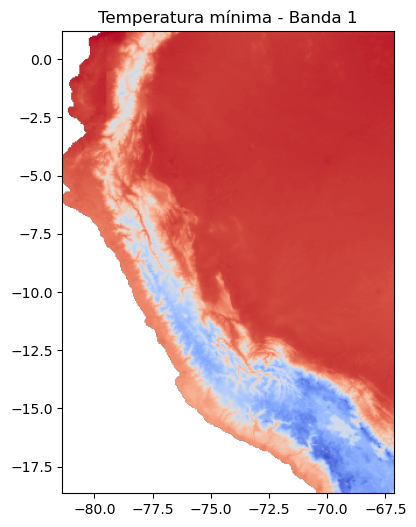

Banda 1: min=nan, max=nan, mean=nan
Banda 2: min=nan, max=nan, mean=nan
Banda 3: min=nan, max=nan, mean=nan
Banda 4: min=nan, max=nan, mean=nan
Banda 5: min=nan, max=nan, mean=nan


In [27]:
# Visualizar una banda (por ejemplo, la primera)
import matplotlib.pyplot as plt
from rasterio.plot import show

fig, ax = plt.subplots(figsize=(6, 6))
show(raster, 1, ax=ax, cmap="coolwarm")
ax.set_title("Temperatura mínima - Banda 1")
plt.show()

# Información de todas las bandas
for i in range(1, raster.count + 1):
    band = raster.read(i)
    print(f"Banda {i}: min={band.min():.2f}, max={band.max():.2f}, mean={band.mean():.2f}")


**Cargar el raster con rioxarray y asignar nombres a las bandas (2020–2024)**

In [29]:
import rioxarray

# Cargar el raster con rioxarray (mantiene metadatos geoespaciales)
tmin = rioxarray.open_rasterio("./data/raw/tmin_raster.tif", masked=True)

# Revisar la estructura del objeto
print(tmin)

# Asignar nombres de banda según los años
años = [2020, 2021, 2022, 2023, 2024]
tmin = tmin.assign_coords(band=años)

print("\n Bandas renombradas:")
print(tmin.band.values)




<xarray.DataArray (band: 5, y: 397, x: 285)> Size: 2MB
[565725 values with dtype=float32]
Coordinates:
  * band         (band) int64 40B 1 2 3 4 5
  * y            (y) float64 3kB 1.175 1.125 1.075 ... -18.53 -18.58 -18.63
  * x            (x) float64 2kB -81.35 -81.3 -81.25 ... -67.26 -67.21 -67.16
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

 Bandas renombradas:
[2020 2021 2022 2023 2024]


In [30]:
# Ver un resumen estadístico general
print("\n Estadísticas descriptivas por año:")
for año in tmin.band.values:
    datos = tmin.sel(band=año)
    print(f"Año {año}: min={float(datos.min()):.2f}, max={float(datos.max()):.2f}, mean={float(datos.mean()):.2f}")


 Estadísticas descriptivas por año:
Año 2020: min=-9.05, max=24.64, mean=18.01
Año 2021: min=-10.02, max=24.39, mean=17.91
Año 2022: min=-9.87, max=24.21, mean=17.77
Año 2023: min=-9.06, max=24.12, mean=17.61
Año 2024: min=-8.85, max=24.15, mean=17.82


## fase de zonal statistics

In [48]:
dist

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,GEOMETRY
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1.0,1.0,"POLYGON ((-77.8858 -6.1778, -77.88323 -6.17846..."
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2.0,2.0,"POLYGON ((-77.74482 -5.94497, -77.74482 -5.945..."
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,3.0,3.0,"POLYGON ((-77.9358 -6.69039, -77.93531 -6.6909..."
3,010104,01,01,04,AMAZONAS,CHACHAPOYAS,CHETO,4.0,4.0,"POLYGON ((-77.71486 -6.24598, -77.71485 -6.245..."
4,010105,01,01,05,AMAZONAS,CHACHAPOYAS,CHILIQUIN,5.0,5.0,"POLYGON ((-77.77405 -5.99598, -77.77328 -5.996..."
...,...,...,...,...,...,...,...,...,...,...
1886,250304,25,03,04,UCAYALI,PADRE ABAD,NESHUYA,1887.0,1887.0,"POLYGON ((-75.01663 -8.44514, -75.0165 -8.4453..."
1887,250305,25,03,05,UCAYALI,PADRE ABAD,ALEXANDER VON HUMBOLDT,1888.0,1888.0,"POLYGON ((-75.02136 -8.73948, -75.02136 -8.739..."
1888,250306,25,03,06,UCAYALI,PADRE ABAD,HUIPOCA,1889.0,1889.0,"POLYGON ((-75.3844 -8.58229, -75.38423 -8.5825..."
1889,250307,25,03,07,UCAYALI,PADRE ABAD,BOQUERON,1890.0,1890.0,"POLYGON ((-75.77583 -8.91013, -75.77427 -8.910..."


In [57]:
import rioxarray
import geopandas as gpd
import os

# 1️⃣ Aseguramos que ambos (raster y shapefile) estén en el mismo CRS
if dist.crs != tmin.rio.crs:
    dist = dist.to_crs(tmin.rio.crs)
    print("Shapefile reproyectado al CRS del raster:", dist.crs)
    
# 2️⃣ Creamos un polígono único de todo el país (para eficiencia)
peru = dist[['GEOMETRY']].dissolve()
print("✅ Geometría de Perú generada")

# 3️⃣ Recorte del raster (todas las bandas)
tmin_dist = tmin.rio.clip(peru.geometry, peru.crs, drop=True)

# 5️⃣ Guardar resultado
tmin_dist_path = "data/processed/tmin_dist_clip.tif"
tmin_dist.rio.to_raster(tmin_dist_path)

print(f"✅ Raster recortado guardado en: {tmin_dist_path}")
print("Dimensiones:", tmin_dist.shape)
print("Bandas:", list(tmin_dist.band.values))
print("CRS:", tmin_dist.rio.crs)

    

✅ Geometría de Perú generada
✅ Raster recortado guardado en: data/processed/tmin_dist_clip.tif
Dimensiones: (5, 366, 253)
Bandas: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
CRS: EPSG:4326


In [68]:
dist

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,GEOMETRY
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1.0,1.0,"POLYGON ((-77.8858 -6.1778, -77.88323 -6.17846..."
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2.0,2.0,"POLYGON ((-77.74482 -5.94497, -77.74482 -5.945..."
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,3.0,3.0,"POLYGON ((-77.9358 -6.69039, -77.93531 -6.6909..."
3,010104,01,01,04,AMAZONAS,CHACHAPOYAS,CHETO,4.0,4.0,"POLYGON ((-77.71486 -6.24598, -77.71485 -6.245..."
4,010105,01,01,05,AMAZONAS,CHACHAPOYAS,CHILIQUIN,5.0,5.0,"POLYGON ((-77.77405 -5.99598, -77.77328 -5.996..."
...,...,...,...,...,...,...,...,...,...,...
1886,250304,25,03,04,UCAYALI,PADRE ABAD,NESHUYA,1887.0,1887.0,"POLYGON ((-75.01663 -8.44514, -75.0165 -8.4453..."
1887,250305,25,03,05,UCAYALI,PADRE ABAD,ALEXANDER VON HUMBOLDT,1888.0,1888.0,"POLYGON ((-75.02136 -8.73948, -75.02136 -8.739..."
1888,250306,25,03,06,UCAYALI,PADRE ABAD,HUIPOCA,1889.0,1889.0,"POLYGON ((-75.3844 -8.58229, -75.38423 -8.5825..."
1889,250307,25,03,07,UCAYALI,PADRE ABAD,BOQUERON,1890.0,1890.0,"POLYGON ((-75.77583 -8.91013, -75.77427 -8.910..."


## estadisticos 

In [77]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
from pathlib import Path

# Opcional: rutas por si quieres reabrir desde disco
# tmin = rioxarray.open_rasterio("data/processed/tmin_dist_clip.tif", masked=True)
# dist = gpd.read_file("data/processed/distritos.shp")

# Alinear CRS entre polígonos y raster (muy importante)
if dist.crs != tmin.rio.crs:
    dist_proj = dist.to_crs(tmin.rio.crs)
else:
    dist_proj = dist

# Garantizar UBIGEO (útil para unir y exportar)
if "UBIGEO" not in dist_proj.columns:
    dist_proj["UBIGEO"] = (
        dist_proj["CCDD"].astype(str).str.zfill(2)
        + dist_proj["CCPP"].astype(str).str.zfill(2)
        + dist_proj["CCDI"].astype(str).str.zfill(2)
    )

# Parámetros raster
affine = tmin.rio.transform()
nodata  = tmin.rio.nodata
if nodata is None:
    nodata = -9999  # define un NODATA explícito si el raster no lo tiene

# Eje temporal / bandas (p.ej. [2020, 2021, 2022, 2023, 2024])
periodos = tmin.coords["band"].values
periodos


array([2020, 2021, 2022, 2023, 2024])

In [82]:
# 3) Helper para limpiar el array que llega a add_stats (evita "read-only" y respeta máscara)
def _vals_clean(x):
    """
    x puede ser ndarray o MaskedArray. Devuelve un vector 1D float,
    copia (writable), sin máscara y sin NaN/Inf.
    """
    mx = np.ma.asarray(x)                     # garantiza masked array
    data = mx.compressed()                    # aplica máscara -> 1D ndarray
    data = np.array(data, dtype=float, copy=True)  # fuerza copia writable
    if data.size == 0:
        return data
    good = np.isfinite(data)                  # filtra NaN/Inf
    return data[good]

In [83]:
# 4) Métricas
base_stats = ["count", "mean", "min", "max", "std"]
add_stats = {
    "p10":      lambda x: np.nan if _vals_clean(x).size == 0 else np.nanpercentile(_vals_clean(x), 10),
    "p90":      lambda x: np.nan if _vals_clean(x).size == 0 else np.nanpercentile(_vals_clean(x), 90),
    "iqr":      lambda x: np.nan if _vals_clean(x).size == 0 else (np.nanpercentile(_vals_clean(x), 75) - np.nanpercentile(_vals_clean(x), 25)),
    "amplitud": lambda x: np.nan if _vals_clean(x).size == 0 else (np.nanmax(_vals_clean(x)) - np.nanmin(_vals_clean(x))),
}

In [84]:
# 5) Tabla de atributos distritales para adjuntar a las métricas
#    (ajustado a tus nombres de columnas reales)
attrs_cols = ["UBIGEO", "CCDD", "CCPP", "CCDI", "DEPARTAMEN", "PROVINCIA", "DISTRITO"]
attrs_cols = [c for c in attrs_cols if c in dist_proj.columns]  # por seguridad
attrs = dist_proj[attrs_cols].reset_index(drop=True)

In [85]:
# 6) Loop por bandas/periodos y cálculo de zonales
resultados = []
for p in periodos:
    # Extrae la banda como matriz 2D (y, x)
    arr = tmin.sel(band=p).values

    # Cálculo de estadísticas zonales
    zs = zonal_stats(
        dist_proj,          # geometrías (distritos)
        arr,                # raster 2D
        affine=affine,
        nodata=nodata,
        stats=base_stats,
        add_stats=add_stats,
        all_touched=False   # True para incluir celdas tocadas en borde
    )

    df = pd.DataFrame(zs)
    df.insert(0, "periodo", p)
    out = pd.concat([attrs.copy(), df], axis=1)
    resultados.append(out)


In [86]:
# 7) Unir todo y renombrar columnas a etiquetas claras
zonal_distritos = pd.concat(resultados, ignore_index=True)
zonal_distritos = zonal_distritos.rename(columns={
    "mean": "tmin_mean",
    "min": "tmin_min",
    "max": "tmin_max",
    "std": "tmin_std",
    "count": "pix_count",
    "p10": "tmin_p10",
    "p90": "tmin_p90",
    "iqr": "tmin_iqr",
    "amplitud": "tmin_amplitud",
})

In [87]:
zonal_distritos.head(5)

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,periodo,tmin_min,tmin_max,tmin_mean,pix_count,tmin_std,tmin_p10,tmin_p90,tmin_iqr,tmin_amplitud
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,2020,11.155586,13.316497,12.559916,6,0.763999,11.549891,13.223657,0.929875,2.160911
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2020,10.110104,10.539493,10.324799,2,0.214694,10.153043,10.496554,0.214694,0.429389
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,2020,9.299319,19.025255,14.643280,11,3.246553,10.763714,18.204876,5.930583,9.725936
3,010104,01,01,04,AMAZONAS,CHACHAPOYAS,CHETO,2020,11.776923,12.021763,11.928758,3,0.108266,11.819056,12.014928,0.122420,0.244840
4,010105,01,01,05,AMAZONAS,CHACHAPOYAS,CHILIQUIN,2020,9.482246,12.857030,11.165710,5,1.144948,9.932108,12.468654,1.279191,3.374784


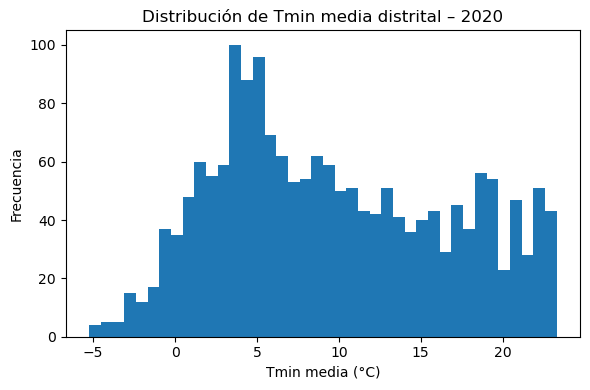

In [88]:
# 9) Validaciones rápidas
# 9.1 Histograma de Tmin media para un año de referencia
anio_plot = periodos[0]  # cambia a un año específico si quieres
tmp = zonal_distritos[zonal_distritos["periodo"] == anio_plot]["tmin_mean"].dropna()

plt.figure(figsize=(6, 4))
plt.hist(tmp, bins=40)
plt.title(f"Distribución de Tmin media distrital – {anio_plot}")
plt.xlabel("Tmin media (°C)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [89]:
# 9.2 Conteo de nulos por año
nulls_por_anio = (
    zonal_distritos
    .groupby("periodo")["tmin_mean"]
    .apply(lambda s: s.isna().sum())
    .rename("n_nulls")
    .reset_index()
)
print(nulls_por_anio)

   periodo  n_nulls
0     2020       86
1     2021       86
2     2022       86
3     2023       86
4     2024       86


<Figure size 800x500 with 0 Axes>

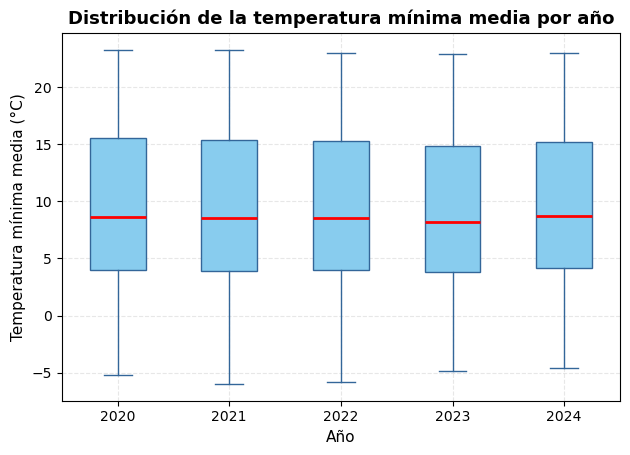

In [93]:
# 9.3 Boxplot de temeperatura minima por año 
plt.figure(figsize=(8, 5))
zonal_distritos.boxplot(
    column="tmin_mean", by="periodo",
    patch_artist=True,
    boxprops=dict(facecolor="#88ccee", color="#336699"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="#336699"),
    capprops=dict(color="#336699"),
    flierprops=dict(marker='o', markersize=3, alpha=0.5, color="#336699")
)
plt.title("Distribución de la temperatura mínima media por año", fontsize=13, weight="bold")
plt.suptitle("")
plt.xlabel("Año", fontsize=11)
plt.ylabel("Temperatura mínima media (°C)", fontsize=11)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


In [135]:
dist

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,GEOMETRY
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1.0,1.0,"POLYGON ((-77.8858 -6.1778, -77.88323 -6.17846..."
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2.0,2.0,"POLYGON ((-77.74482 -5.94497, -77.74482 -5.945..."
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,3.0,3.0,"POLYGON ((-77.9358 -6.69039, -77.93531 -6.6909..."
3,010104,01,01,04,AMAZONAS,CHACHAPOYAS,CHETO,4.0,4.0,"POLYGON ((-77.71486 -6.24598, -77.71485 -6.245..."
4,010105,01,01,05,AMAZONAS,CHACHAPOYAS,CHILIQUIN,5.0,5.0,"POLYGON ((-77.77405 -5.99598, -77.77328 -5.996..."
...,...,...,...,...,...,...,...,...,...,...
1886,250304,25,03,04,UCAYALI,PADRE ABAD,NESHUYA,1887.0,1887.0,"POLYGON ((-75.01663 -8.44514, -75.0165 -8.4453..."
1887,250305,25,03,05,UCAYALI,PADRE ABAD,ALEXANDER VON HUMBOLDT,1888.0,1888.0,"POLYGON ((-75.02136 -8.73948, -75.02136 -8.739..."
1888,250306,25,03,06,UCAYALI,PADRE ABAD,HUIPOCA,1889.0,1889.0,"POLYGON ((-75.3844 -8.58229, -75.38423 -8.5825..."
1889,250307,25,03,07,UCAYALI,PADRE ABAD,BOQUERON,1890.0,1890.0,"POLYGON ((-75.77583 -8.91013, -75.77427 -8.910..."


#Importamos shapefile procesado 

In [139]:
import geopandas as gpd
from rasterstats import zonal_stats
import pandas as pd
from shapely.geometry import box
import numpy as np
import pandas as pd


# Ruta a shapefile procesado
shp_path = "./data/processed/distritos.shp"

# Cargar shapefile
dist = gpd.read_file(shp_path) 

In [140]:

# --- helpers seguros ---
def _vals_clean(x):
    mx = np.ma.asarray(x)
    v  = mx.compressed()                      # quita máscara -> 1D
    if v.size == 0:
        return np.array([], dtype=float)
    v = np.array(v, dtype=float, copy=True)   # copia = writable
    v = v[np.isfinite(v)]                     # sin NaN/Inf
    return v

def p10_safe(x):
    v = _vals_clean(x)
    return np.nan if v.size == 0 else np.nanpercentile(v, 10)

def p90_safe(x):
    v = _vals_clean(x)
    return np.nan if v.size == 0 else np.nanpercentile(v, 90)

def amplitud_safe(x):
    v = _vals_clean(x)
    return np.nan if v.size == 0 else (np.nanmax(v) - np.nanmin(v))

# --- (opcional) filtra distritos que caen dentro del extent del raster ---
# si ya tienes `tmin` (rioxarray) cargado:
# if dist.crs != tmin.rio.crs:
#     dist_in = dist.to_crs(tmin.rio.crs)
# else:
#     dist_in = dist.copy()
# bbox = box(*tmin.rio.bounds())
# dist_in = dist_in[dist_in.intersects(bbox)].copy()
# si no, usa todo dist:
dist_in = dist

anios_dist = [2020, 2021, 2022, 2023, 2024]
estadisticos_dist = ["count", "mean", "min", "max", "std", "median",
                     "percentile_10", "percentile_90", "amplitud"]
acum_dist = {stat: [] for stat in estadisticos_dist}

for año in anios_dist:
    stats_dist = zonal_stats(
        dist_in,
        "./data/raw/tmin_raster.tif",
        stats=["count", "mean", "min", "max", "std", "median"],
        add_stats={
            "percentile_10": p10_safe,
            "percentile_90": p90_safe,
            "amplitud":      amplitud_safe,
        },
        band=(año - 2019),
        geojson_out=False,
        nodata=None,          # si tu TIFF tiene NODATA, ponlo aquí (ej. -9999)
        all_touched=False
    )
    df_dist = pd.DataFrame(stats_dist)
    for stat in estadisticos_dist:
        if stat in df_dist.columns:
            acum_dist[stat].append(df_dist[stat].to_numpy())

# promedios 2020–2024 por estadístico; se agregan a dist_in
for stat, listas in acum_dist.items():
    if len(listas) == len(anios_dist) and len(listas) > 0:
        arr = np.vstack(listas)                 # (5, n_distritos_validos)
        dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)

# vuelca a 'dist' (alineación por índice; donde no intersecta queda NaN)
for col in dist_in.columns:
    if col.startswith("tmin_") and col.endswith("_total"):
        dist[col] = dist_in[col]

cols_totales_dist = [c for c in dist.columns if c.startswith("tmin_") and c.endswith("_total")]
print("Columnas totales creadas:", cols_totales_dist)
print(dist[["DISTRITO"] + cols_totales_dist].head())


Columnas totales creadas: ['tmin_count_total', 'tmin_mean_total', 'tmin_min_total', 'tmin_max_total', 'tmin_std_total', 'tmin_median_total', 'tmin_percentile_10_total', 'tmin_percentile_90_total', 'tmin_amplitud_total']
      DISTRITO  tmin_count_total  tmin_mean_total  tmin_min_total  \
0  CHACHAPOYAS               6.0        12.403868       11.032648   
1     ASUNCION               2.0        10.232676       10.029134   
2       BALSAS              11.0        14.492733        9.164226   
3        CHETO               3.0        11.770264       11.627967   
4    CHILIQUIN               5.0        11.065167        9.423780   

   tmin_max_total  tmin_std_total  tmin_median_total  \
0       13.120787        0.744316          12.742976   
1       10.436218        0.203542          10.232676   
2       18.931234        3.263794          15.668368   
3       11.850517        0.100983          11.832309   
4       12.711129        1.117485          10.918611   

   tmin_percentile_10_total 

/var/folders/cx/g5gs5tnx3m3bprnnzxq291_40000gn/T/ipykernel_6786/2549981370.py:63: RuntimeWarning: Mean of empty slice
  dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)
/var/folders/cx/g5gs5tnx3m3bprnnzxq291_40000gn/T/ipykernel_6786/2549981370.py:63: RuntimeWarning: Mean of empty slice
  dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)
/var/folders/cx/g5gs5tnx3m3bprnnzxq291_40000gn/T/ipykernel_6786/2549981370.py:63: RuntimeWarning: Mean of empty slice
  dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)
/var/folders/cx/g5gs5tnx3m3bprnnzxq291_40000gn/T/ipykernel_6786/2549981370.py:63: RuntimeWarning: Mean of empty slice
  dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)
/var/folders/cx/g5gs5tnx3m3bprnnzxq291_40000gn/T/ipykernel_6786/2549981370.py:63: RuntimeWarning: Mean of empty slice
  dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)
/var/folders/cx/g5gs5tnx3m3bprnnzxq291_40000gn/T/ipykernel_6786/2549981370.py:63: RuntimeWarning: Mean of empty slice
  

In [141]:
dist

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,geometry,tmin_count_total,tmin_mean_total,tmin_min_total,tmin_max_total,tmin_std_total,tmin_median_total,tmin_percentile_10_total,tmin_percentile_90_total,tmin_amplitud_total
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1.0,1.0,"POLYGON ((-77.8858 -6.1778, -77.88323 -6.17846...",6.0,12.403868,11.032648,13.120787,0.744316,12.742976,11.418373,13.050255,2.088139
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2.0,2.0,"POLYGON ((-77.74482 -5.94497, -77.74482 -5.945...",2.0,10.232676,10.029134,10.436218,0.203542,10.232676,10.069842,10.395510,0.407085
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,3.0,3.0,"POLYGON ((-77.9358 -6.69039, -77.93531 -6.6909...",11.0,14.492733,9.164226,18.931234,3.263794,15.668368,10.584344,18.079209,9.767008
3,010104,01,01,04,AMAZONAS,CHACHAPOYAS,CHETO,4.0,4.0,"POLYGON ((-77.71486 -6.24598, -77.71485 -6.245...",3.0,11.770264,11.627967,11.850517,0.100983,11.832309,11.668836,11.846875,0.222549
4,010105,01,01,05,AMAZONAS,CHACHAPOYAS,CHILIQUIN,5.0,5.0,"POLYGON ((-77.77405 -5.99598, -77.77328 -5.996...",5.0,11.065167,9.423780,12.711129,1.117485,10.918611,9.854567,12.335305,3.287350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1886,250304,25,03,04,UCAYALI,PADRE ABAD,NESHUYA,1887.0,1887.0,"POLYGON ((-75.01663 -8.44514, -75.0165 -8.4453...",22.0,21.937903,21.727421,22.180375,0.133436,21.905812,21.771170,22.140653,0.452954
1887,250305,25,03,05,UCAYALI,PADRE ABAD,ALEXANDER VON HUMBOLDT,1888.0,1888.0,"POLYGON ((-75.02136 -8.73948, -75.02136 -8.739...",6.0,21.862907,21.730026,21.946946,0.080880,21.892983,21.756207,21.939533,0.216920
1888,250306,25,03,06,UCAYALI,PADRE ABAD,HUIPOCA,1889.0,1889.0,"POLYGON ((-75.3844 -8.58229, -75.38423 -8.5825...",18.0,22.090904,21.916062,22.266233,0.090198,22.106946,21.978192,22.179917,0.350171
1889,250307,25,03,07,UCAYALI,PADRE ABAD,BOQUERON,1890.0,1890.0,"POLYGON ((-75.77583 -8.91013, -75.77427 -8.910...",19.0,17.905087,14.919734,21.548261,1.710479,17.815664,15.770541,19.830037,6.628527


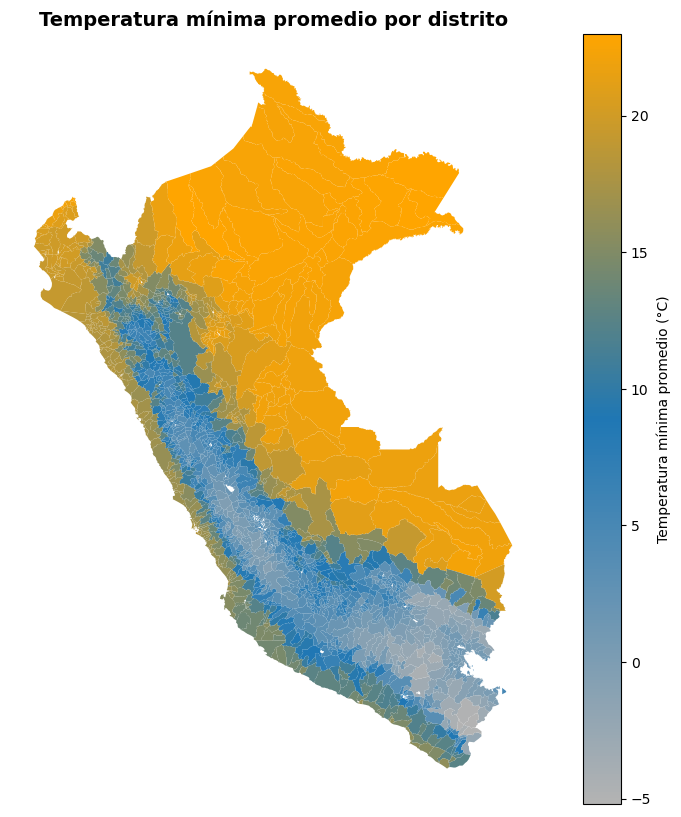


Columnas disponibles en el dataframe:
['UBIGEO', 'CCDD', 'CCPP', 'CCDI', 'DEPARTAMEN', 'PROVINCIA', 'DISTRITO', 'OBJECTID', 'ESRI_OID', 'geometry', 'tmin_count_total', 'tmin_mean_total', 'tmin_min_total', 'tmin_max_total', 'tmin_std_total', 'tmin_median_total', 'tmin_percentile_10_total', 'tmin_percentile_90_total', 'tmin_amplitud_total']


In [152]:
# Visualizar los resultados en un mapa
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

colors = ["#b3b3b3", "#1f77b4", "#ffa500"]  # gris → azul → anaranjado
cmap_custom = LinearSegmentedColormap.from_list("FrioAzulNaranja", colors, N=256)

# 🗺️ Graficar el mapa
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
dist.plot(
    column="tmin_mean_total",
    ax=ax,
    legend=True,
    cmap=cmap_custom,
    legend_kwds={
        'label': "Temperatura mínima promedio (°C)",
        'orientation': 'vertical'
    }
)
ax.set_title("Temperatura mínima promedio por distrito", fontsize=14, fontweight="bold")
ax.axis("off")
plt.show()

print("\nColumnas disponibles en el dataframe:")
print(dist.columns.tolist())

In [153]:
# Histogramas
for col in stats_cols:
    plt.figure(figsize=(7,4))
    dist[col].hist(bins=30)
    plt.title(f"Histograma: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.2)
    plt.show()

NameError: name 'stats_cols' is not defined

## Otra opcion: estaditicos por regiones 

Próximo paso: unir raster + shapefiles

Como el raster ya está en rioxarray, se puede calcular estadísticas directamente sobre cada polígono (departamento, provincia o distrito).

Te dejo ejemplo de GTP sin revisar, si te ayuda

In [102]:
dept

,CCDD,DEPARTAMEN,OBJECTID,ESRI_OID,geometry
0,01,AMAZONAS,1.0,1.0,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995..."
1,02,ANCASH,2.0,2.0,"POLYGON ((-77.64697 -8.05086, -77.64689 -8.051..."
2,03,APURIMAC,3.0,3.0,"POLYGON ((-73.74655 -13.17442, -73.7457 -13.17..."
3,04,AREQUIPA,4.0,4.0,"POLYGON ((-71.98109 -14.64062, -71.98093 -14.6..."
4,05,AYACUCHO,5.0,5.0,"POLYGON ((-74.34843 -12.17503, -74.35 -12.1758..."
5,06,CAJAMARCA,6.0,6.0,"POLYGON ((-78.70034 -4.62769, -78.69817 -4.629..."
6,07,CALLAO,7.0,7.0,"POLYGON ((-77.13504 -11.8182, -77.13484 -11.81..."
7,08,CUSCO,8.0,8.0,"POLYGON ((-72.9728 -11.25189, -72.97134 -11.25..."
8,09,HUANCAVELICA,9.0,9.0,"POLYGON ((-74.57118 -11.9871, -74.57095 -11.98..."
9,10,HUANUCO,10.0,10.0,"POLYGON ((-75.992 -8.32108, -75.99015 -8.32171..."


In [95]:
import geopandas as gpd
from rasterstats import zonal_stats
import pandas as pd

# Ruta a shapefile procesado
shp_path = "./data/processed/departamentos.shp"

# Cargar shapefile
dept = gpd.read_file(shp_path) 

In [133]:
# Años/bandas del ráster
anios = [2020, 2021, 2022, 2023, 2024]

# Estadísticos a calcular (incluye amplitud = max - min)
estadisticos = ["count", "mean", "min", "max", "std", "median", "percentile_10", "percentile_90", "amplitud"]

# Acumulador: por cada estadístico, una lista de arrays (uno por año)
acum = {stat: [] for stat in estadisticos}

# Loop por año (NO creamos columnas por año)
for año in anios:
    stats = zonal_stats(
        dept,
        "./data/raw/tmin_raster.tif",
        stats=["count", "mean", "min", "max", "std", "median"],   # base
        add_stats={
            "percentile_10": lambda x: np.nanpercentile(np.ma.compressed(x), 10),
            "percentile_90": lambda x: np.nanpercentile(np.ma.compressed(x), 90),
            "amplitud":      lambda x: (np.nanmax(np.ma.compressed(x)) - np.nanmin(np.ma.compressed(x))),
        },
        band=(año - 2019),  # 2020→1, 2021→2, ...
        geojson_out=False,
        nodata=None,
        all_touched=False
    )
    df = pd.DataFrame(stats)

    # Guardar vectores (uno por estadístico) para este año
    for stat in estadisticos:
        if stat in df.columns:
            acum[stat].append(df[stat].to_numpy())

# Calcular SOLO los promedios totales (2020–2024) y agregarlos a `dept`
for stat, listas in acum.items():
    if len(listas) == len(anios) and len(listas) > 0:
        # apilar años -> (n_years, n_features) y promediar por filas
        arr = np.vstack(listas)                        # shape: (5, n_deptos)
        dept[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)

# Verifica columnas creadas (solo *_total)
cols_totales = [c for c in dept.columns if c.startswith("tmin_") and c.endswith("_total")]
print("Columnas totales creadas:", cols_totales)
print(dept[["DEPARTAMEN"] + cols_totales].head())


Columnas totales creadas: ['tmin_count_total', 'tmin_mean_total', 'tmin_min_total', 'tmin_max_total', 'tmin_std_total', 'tmin_median_total', 'tmin_percentile_10_total', 'tmin_percentile_90_total', 'tmin_amplitud_total']
  DEPARTAMEN  tmin_count_total  tmin_mean_total  tmin_min_total  \
0   AMAZONAS            1274.0        17.740650        5.449544   
1     ANCASH            1190.0         9.204708       -0.159098   
2   APURIMAC             711.0         4.481046       -1.854122   
3   AREQUIPA            2124.0         6.380742       -6.064533   
4   AYACUCHO            1454.0         5.948239       -0.877300   

   tmin_max_total  tmin_std_total  tmin_median_total  \
0       23.075594        4.362627          19.272255   
1       18.110587        5.526664           7.963560   
2       15.218701        3.555178           3.740294   
3       17.383959        6.929188           8.146554   
4       19.184651        3.946828           4.891810   

   tmin_percentile_10_total  tmin_percen

In [134]:
dept.head(5)

,CCDD,DEPARTAMEN,OBJECTID,ESRI_OID,geometry,tmin_count_total,tmin_mean_total,tmin_min_total,tmin_max_total,tmin_std_total,tmin_median_total,tmin_percentile_10_total,tmin_percentile_90_total,tmin_amplitud_total
0,01,AMAZONAS,1.0,1.0,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995...",1274.0,17.740650,5.449544,23.075594,4.362627,19.272255,10.950419,22.493336,17.626049
1,02,ANCASH,2.0,2.0,"POLYGON ((-77.64697 -8.05086, -77.64689 -8.051...",1190.0,9.204708,-0.159098,18.110587,5.526664,7.963560,2.729118,17.161034,18.269686
2,03,APURIMAC,3.0,3.0,"POLYGON ((-73.74655 -13.17442, -73.7457 -13.17...",711.0,4.481046,-1.854122,15.218701,3.555178,3.740294,0.578278,9.767550,17.072824
3,04,AREQUIPA,4.0,4.0,"POLYGON ((-71.98109 -14.64062, -71.98093 -14.6...",2124.0,6.380742,-6.064533,17.383959,6.929188,8.146554,-2.977380,14.398570,23.448490
4,05,AYACUCHO,5.0,5.0,"POLYGON ((-74.34843 -12.17503, -74.35 -12.1758...",1454.0,5.948239,-0.877300,19.184651,3.946828,4.891810,1.947629,11.799845,20.061951


In [110]:


resultados = []  # cada elemento será la lista de 'mean' por departamento para un año

for año in [2020, 2021, 2022, 2023, 2024]:
    stats = zonal_stats(
        dept,                               # GeoDataFrame de departamentos
        "./data/raw/tmin_raster.tif",       # ráster multibanda
        stats=["count", "mean", "min", "max", "std", "median"],
        add_stats={
            "percentile_10": lambda x: np.nanpercentile(np.ma.compressed(x), 10),
            "percentile_90": lambda x: np.nanpercentile(np.ma.compressed(x), 90),
        },
        band=(año - 2019),                  # 2020->1, 2021->2, ...
        geojson_out=False,
        nodata=None,
        all_touched=False
    )
    # ⬇️ ESTA LÍNEA DEBE ESTAR DENTRO DEL FOR
    resultados.append([s["mean"] for s in stats])

# Crear columnas por banda (o por año, si prefieres)
for i, valores in enumerate(resultados):
    dept[f"tmin_banda{i+1}"] = valores          # banda1..banda5
    # o: dept[f"tmin_{2020+i}"] = valores       # 2020..2024

# Promedio total de las 5 bandas (en 'dept', no en 'gdf')
dept["tmin_promedio_total"] = dept[[f"tmin_banda{i+1}" for i in range(5)]].mean(axis=1)
# si usaste por año: dept["tmin_promedio_total"] = dept[[f"tmin_{y}" for y in [2020,2021,2022,2023,2024]]].mean(axis=1)

# Mostrar
print(dept[["DEPARTAMEN", "tmin_promedio_total"]].head())


  DEPARTAMEN  tmin_promedio_total
0   AMAZONAS            17.740650
1     ANCASH             9.204708
2   APURIMAC             4.481046
3   AREQUIPA             6.380742
4   AYACUCHO             5.948239


In [112]:
dept.head(5)

,CCDD,DEPARTAMEN,OBJECTID,ESRI_OID,geometry,tmin_banda1,tmin_banda2,tmin_banda3,tmin_banda4,tmin_banda5,...,20201,20202,20203,20204,20205,tmin_año1,tmin_año2,tmin_año3,tmin_año4,tmin_año5
0,01,AMAZONAS,1.0,1.0,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995...",17.938512,17.857031,17.694592,17.459713,17.753403,...,17.938512,17.857031,17.694592,17.459713,17.753403,17.938512,17.857031,17.694592,17.459713,17.753403
1,02,ANCASH,2.0,2.0,"POLYGON ((-77.64697 -8.05086, -77.64689 -8.051...",9.466574,9.304433,9.168610,8.800611,9.283315,...,9.466574,9.304433,9.168610,8.800611,9.283315,9.466574,9.304433,9.168610,8.800611,9.283315
2,03,APURIMAC,3.0,3.0,"POLYGON ((-73.74655 -13.17442, -73.7457 -13.17...",4.454030,4.386174,4.549570,4.338425,4.677033,...,4.454030,4.386174,4.549570,4.338425,4.677033,4.454030,4.386174,4.549570,4.338425,4.677033
3,04,AREQUIPA,4.0,4.0,"POLYGON ((-71.98109 -14.64062, -71.98093 -14.6...",6.602211,6.331513,6.365915,6.059656,6.544417,...,6.602211,6.331513,6.365915,6.059656,6.544417,6.602211,6.331513,6.365915,6.059656,6.544417
4,05,AYACUCHO,5.0,5.0,"POLYGON ((-74.34843 -12.17503, -74.35 -12.1758...",5.995176,5.905022,5.993040,5.709010,6.138944,...,5.995176,5.905022,5.993040,5.709010,6.138944,5.995176,5.905022,5.993040,5.709010,6.138944


In [99]:
resultados

[          min        max       mean       std     median  percentile_10  \
 0    5.607545  23.357122  17.938512  4.415945  19.482910      11.045912   
 1   -0.114301  18.689566   9.466574  5.745750   8.101915       2.795856   
 2   -1.771683  15.225024   4.454030  3.536285   3.724304       0.559477   
 3   -5.922765  17.838457   6.602211  6.992906   8.379168      -2.805674   
 4   -0.792948  19.389566   5.995176  3.949300   4.907458       2.020190   
 5    4.604817  21.459833  12.896788  4.172748  12.991574       6.976535   
 6   17.608805  18.408934  17.863834  0.281944  17.779911      17.645927   
 7   -6.198120  22.636209   9.019368  8.263553   7.660058      -0.891095   
 8   -1.698617  15.772893   3.822584  3.952307   2.842624      -0.556065   
 9    0.268243  22.860834  13.378673  6.668933  13.174327       4.787189   
 10   0.146446  17.855211  14.108443  2.423862  14.666621      11.491340   
 11  -1.744987  22.591087  10.228214  7.749270  10.191409       0.585798   
 12   4.1417

In [100]:
# Combinar todos los resultados
tmin_dept = pd.concat(resultados)
tmin_dept.reset_index(drop=True, inplace=True)

In [101]:
print("Estadísticas zonales calculadas correctamente")
tmin_dept.head()

Estadísticas zonales calculadas correctamente


,min,max,mean,std,median,percentile_10,percentile_90,AÑO,DEPARTAMENTO
0,5.607545,23.357122,17.938512,4.415945,19.482910,11.045912,22.771120,2020,AMAZONAS
1,-0.114301,18.689566,9.466574,5.745750,8.101915,2.795856,17.856094,2020,ANCASH
2,-1.771683,15.225024,4.454030,3.536285,3.724304,0.559477,9.713305,2020,APURIMAC
3,-5.922765,17.838457,6.602211,6.992906,8.379168,-2.805674,14.752823,2020,AREQUIPA
4,-0.792948,19.389566,5.995176,3.949300,4.907458,2.020190,11.851123,2020,AYACUCHO


In [41]:
import geopandas as gpd
from rasterstats import zonal_stats
import pandas as pd

# Ruta a shapefile procesado
shp_path = "../data/processed/departamentos.shp"

# Cargar shapefile
dept = gpd.read_file(shp_path)

# Calcular estadísticas zonales por año
resultados = []

for año in [2020, 2021, 2022, 2023, 2024]:
    stats = zonal_stats(
        dept,
        f"../data/raw/tmin_raster.tif",
        stats=["mean", "min", "max", "std", "median", "percentile_10", "percentile_90"],
        band=[año - 2019],  # banda 1=2020, etc.
        geojson_out=False,
        nodata=None
    )
    
    df_stats = pd.DataFrame(stats)
    df_stats["AÑO"] = año
    df_stats["DEPARTAMENTO"] = dept["DEPARTAMEN"].values
    resultados.append(df_stats)

# Combinar todos los resultados
tmin_dept = pd.concat(resultados)
tmin_dept.reset_index(drop=True, inplace=True)

print("Estadísticas zonales calculadas correctamente")
tmin_dept.head()


DataSourceError: ../data/processed/departamentos.shp: No such file or directory

In [31]:
dist

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,GEOMETRY
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1.0,1.0,"POLYGON ((-77.8858 -6.1778, -77.88323 -6.17846..."
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2.0,2.0,"POLYGON ((-77.74482 -5.94497, -77.74482 -5.945..."
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,3.0,3.0,"POLYGON ((-77.9358 -6.69039, -77.93531 -6.6909..."
3,010104,01,01,04,AMAZONAS,CHACHAPOYAS,CHETO,4.0,4.0,"POLYGON ((-77.71486 -6.24598, -77.71485 -6.245..."
4,010105,01,01,05,AMAZONAS,CHACHAPOYAS,CHILIQUIN,5.0,5.0,"POLYGON ((-77.77405 -5.99598, -77.77328 -5.996..."
...,...,...,...,...,...,...,...,...,...,...
1886,250304,25,03,04,UCAYALI,PADRE ABAD,NESHUYA,1887.0,1887.0,"POLYGON ((-75.01663 -8.44514, -75.0165 -8.4453..."
1887,250305,25,03,05,UCAYALI,PADRE ABAD,ALEXANDER VON HUMBOLDT,1888.0,1888.0,"POLYGON ((-75.02136 -8.73948, -75.02136 -8.739..."
1888,250306,25,03,06,UCAYALI,PADRE ABAD,HUIPOCA,1889.0,1889.0,"POLYGON ((-75.3844 -8.58229, -75.38423 -8.5825..."
1889,250307,25,03,07,UCAYALI,PADRE ABAD,BOQUERON,1890.0,1890.0,"POLYGON ((-75.77583 -8.91013, -75.77427 -8.910..."


 ## Recorte del ráster completo (las 5 bandas) a Perú usando los distritos

In [39]:
tmin

<xarray.DataArray (band: 5, y: 397, x: 285)> Size: 2MB
[565725 values with dtype=float32]
Coordinates:
  * band         (band) int64 40B 2020 2021 2022 2023 2024
  * y            (y) float64 3kB 1.175 1.125 1.075 ... -18.53 -18.58 -18.63
  * x            (x) float64 2kB -81.35 -81.3 -81.25 ... -67.26 -67.21 -67.16
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [44]:
from rasterio.mask import mask

# Abrir y recortar todas las bandas del ráster
with rasterio.open("raster_path") as src:
    out_image, out_transform = mask(src, dist.geometry, crop=True)
    out_meta = src.meta.copy()

RasterioIOError: raster_path: No such file or directory

In [40]:
from rasterio.mask import mask

# Abrir y recortar todas las bandas del ráster
with rasterio.open("tmin") as src:
    out_image, out_transform = mask(src, dist.geometry, crop=True)
    out_meta = src.meta.copy()

out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Guardar el nuevo ráster recortado
with rasterio.open("tmin_raster_dist.tif", "w", **out_meta) as dest:
    dest.write(out_image)

RasterioIOError: tmin: No such file or directory